**Import Libraries**

In [56]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as ex
from imblearn.over_sampling import SMOTE
import joblib

%matplotlib inline
background_color = "#f6f6f6"
RANDOM_STATE = 42


**Load Dataset**

In [2]:
df = pd.read_csv("C:/Users/user/Downloads/healthcare-dataset-stroke-data.csv")

# df = pd.read_csv("/healthcare-dataset-stroke-data.csv")
df.sample(5)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1825,23561,Female,48.0,0,0,Yes,Private,Rural,84.56,41.8,never smoked,0
3623,13817,Male,19.0,0,0,No,Private,Urban,123.61,25.2,Other,0
4770,21963,Male,31.0,0,0,Yes,Private,Urban,108.51,26.7,Other,0
3351,58466,Male,77.0,0,0,Yes,Private,Rural,98.84,27.3,Other,0
4349,28513,Female,73.0,0,0,Yes,Private,Rural,88.98,20.6,smokes,0


**Check Dataset Size**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 5110
Number of columns: 12


**Display Columns and it data type**

In [4]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

**Check missing value**

In [5]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

The id column is only a patient identifier.
It does not represent a meaningful health characteristic.

**Remove ID Column**

In [6]:
df = df.drop('id', axis=1)

In [7]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.9,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Check Duplicate Data**

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Data cleaning fixes**

1. **Missing `bmi` values (201 rows)** — imputed with the median.
2. **Rare `'Other'` category in `gender` (1 row)** — removed. It's also too small a sample (n=1) for the model to learn anything from, and would break the EDA bar charts below since it creates a mismatched category count between the stroke/no-stroke groups.

In [9]:
print("Missing bmi before:", df['bmi'].isnull().sum())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print("Missing bmi after:", df['bmi'].isnull().sum())


Missing bmi before: 0
Missing bmi after: 0


In [10]:
print("Rows before:", df.shape[0])
df = df[df['gender'] != 'Other']
print("Rows after removing 'Other' gender:", df.shape[0])


Rows before: 5110
Rows after removing 'Other' gender: 5110


# Explore Data Analysis

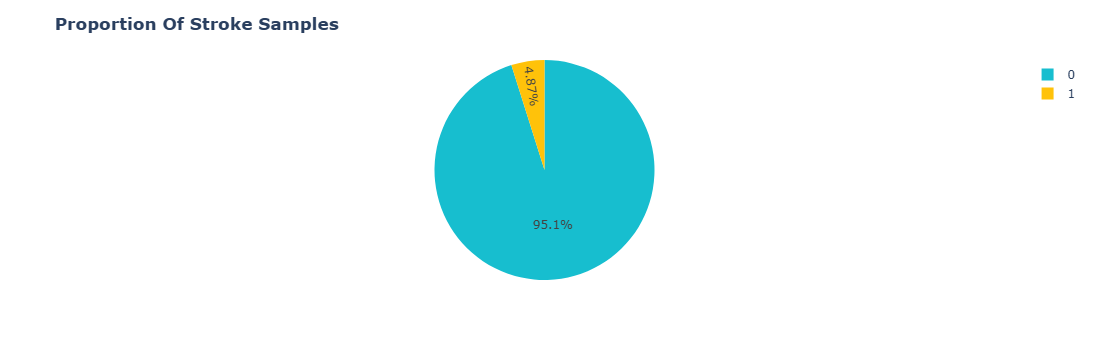

In [11]:
fig = ex.pie(df, names='stroke', color_discrete_sequence=['#17BECF', '#FFC20A'])
fig.update_layout(title='<b>Proportion Of Stroke Samples<b>')
fig.show()


we can clearly see the dataset is unbalanced, so we will oversample it using the SMOTE approach later, before training the Random Forest model

**Age Distribution**

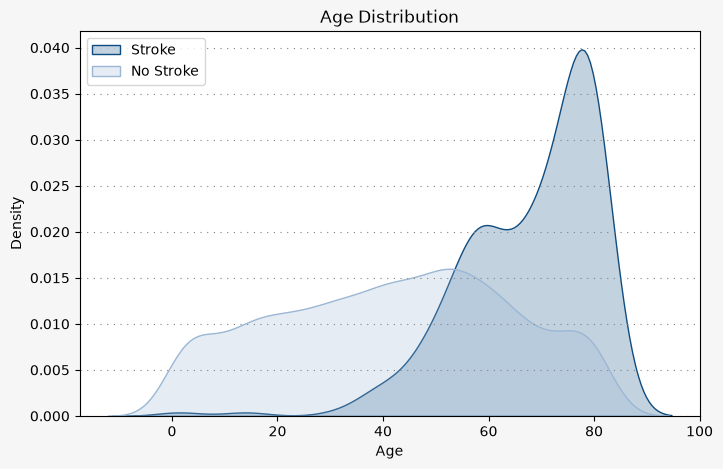

In [12]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

ax.grid(color='gray', linestyle=':', axis='y', dashes=(1,5))

positive = pd.DataFrame(str_only["age"])
negative = pd.DataFrame(no_str_only["age"])

sns.kdeplot(positive["age"], ax=ax, color="#0f4c81", fill=True, label="Stroke")
sns.kdeplot(negative["age"], ax=ax, color="#9bb7d4", fill=True, label="No Stroke")

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()

plt.show()


**Smoking Status**

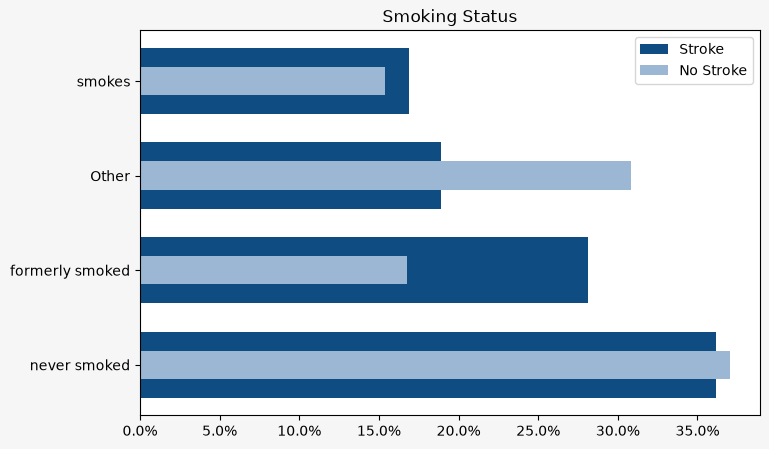

In [13]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["smoking_status"].value_counts())
positive["Percentage"] = (positive["count"] / positive["count"].sum()) * 100

negative = pd.DataFrame(no_str_only["smoking_status"].value_counts())
negative["Percentage"] = (negative["count"] / negative["count"].sum()) * 100

ax.barh(positive.index, positive["Percentage"], color="#0f4c81", height=0.7, label="Stroke")
ax.barh(negative.index, negative["Percentage"], color="#9bb7d4", height=0.3, label="No Stroke")

ax.set_title("Smoking Status")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.show()


**Gender**

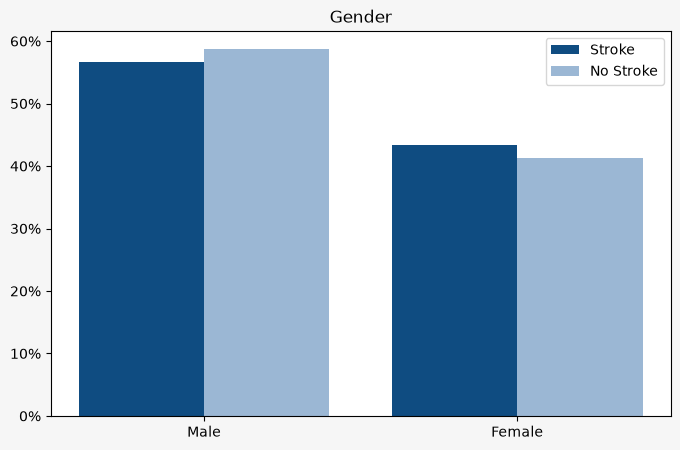

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["gender"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["gender"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["Male","Female"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gender")
ax.legend()

plt.show()


**Heart Disease**

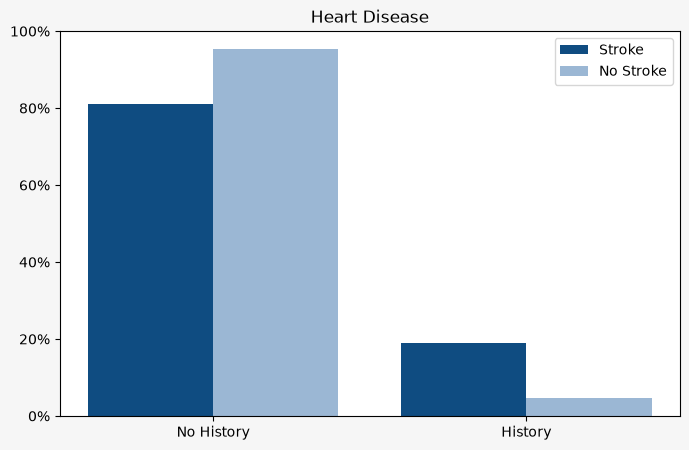

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["heart_disease"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["heart_disease"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Heart Disease")
ax.legend()

plt.show()


**Average Glucose Level**

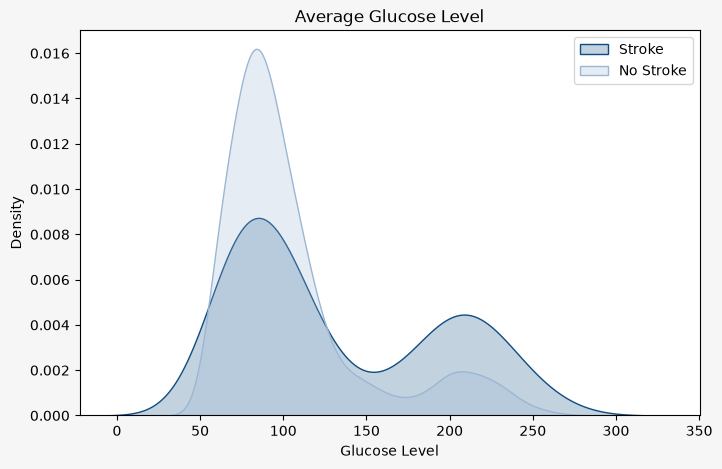

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["avg_glucose_level"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["avg_glucose_level"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("Average Glucose Level")
ax.set_xlabel("Glucose Level")
ax.legend()

plt.show()


**BMI**

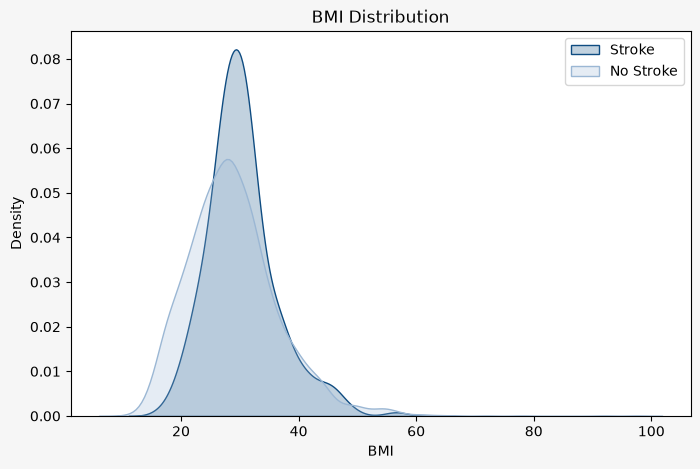

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["bmi"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["bmi"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()

plt.show()


**Work Type**

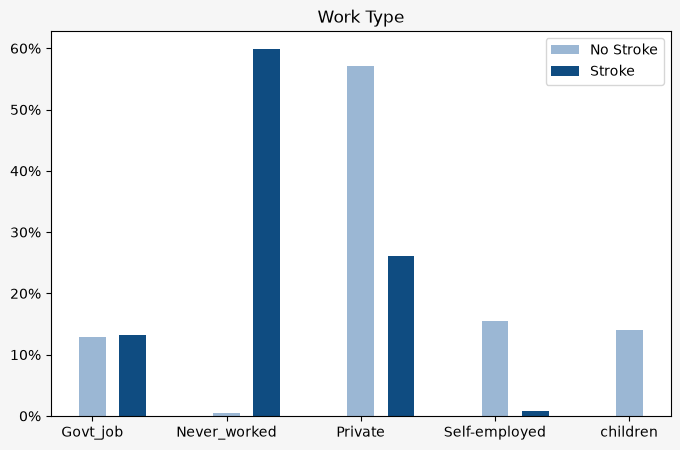

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["work_type"].value_counts()).sort_index()
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["work_type"].value_counts()).sort_index()
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

ax.bar(negative.index, negative["Percentage"], width=0.2, color="#9bb7d4", label="No Stroke")
ax.bar(np.arange(len(positive))+0.3, positive["Percentage"], width=0.2, color="#0f4c81", label="Stroke")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Work Type")
ax.legend()

plt.show()


**Hypertension**

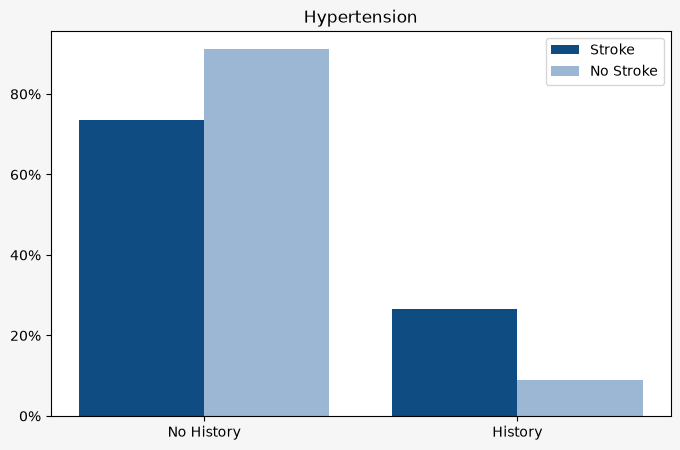

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Hypertension")
ax.legend()

plt.show()


**Find unique data in each column**

In [20]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


# Label Encoding

**ever_married**

Note: `df[col].replace(..., inplace=True)` is avoided here — with newer pandas versions (copy-on-write),
this chained-assignment pattern silently fails to update the DataFrame. Using `df[col] = df[col].replace(...)`
instead, which is safe on all pandas versions.

In [21]:
df['ever_married'] = df['ever_married'].replace({'Yes':1,'No':0})

In [22]:
print(f'ever_married : {df["ever_married"].unique()}')

ever_married : [1 0]


**convert into integer**

In [23]:
df.ever_married=pd.to_numeric(df.ever_married)

**gender**

In [24]:
df['gender'] = df['gender'].replace({'Male':1,'Female':0})

In [25]:
print(f'gender : {df["gender"].unique()}')

gender : [1 0]


**convert into integer**

In [26]:
df.gender=pd.to_numeric(df.gender)

# One Hot Encoding

In [27]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


**now we will use one hot encoding for work type, resident type and smoking status**

In [28]:
df = pd.get_dummies(data=df, columns=['work_type','Residence_type','smoking_status'], drop_first=True)
df.sample(5)


,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1774,0,12.00,0,0,0,81.66,23.5,0,False,False,False,True,False,True,False,False
1206,0,0.72,0,0,0,66.36,23.0,0,False,False,False,True,True,False,False,False
4509,1,16.00,0,0,0,82.95,21.4,0,False,True,False,False,True,False,True,False
2371,1,25.00,0,0,0,65.77,23.7,0,False,True,False,False,False,False,False,True
3752,0,57.00,1,0,1,108.61,38.1,0,False,True,False,False,True,False,False,True


In [29]:
df.dtypes

gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Urban                 bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

# Train/Test Split

Unlike the SVM notebook (which scales before splitting), the split is done **first** here, and scaling/SMOTE are
fit only on the training set. This avoids data leakage from the test set into the preprocessing steps — standard
practice for a Random Forest pipeline that will later be evaluated on unseen data.

In [30]:
X = df.drop('stroke', axis='columns')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


In [31]:
X_train.shape

(4088, 15)

In [32]:
X_test.shape

(1022, 15)

# Feature Scaling

Scaling `age`, `avg_glucose_level` and `bmi` with `StandardScaler`, fit on the training data only and then
applied to the test data — this keeps the test set completely unseen during preprocessing.

In [33]:
numeric_cols = ['age','avg_glucose_level','bmi']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.sample(5)


,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
817,1,-1.387679,0,0,0,-0.893558,-0.672877,False,False,False,True,False,False,False,False
1238,0,-0.989344,0,0,0,0.133973,-0.403501,False,True,False,False,False,False,False,False
4394,0,-0.945084,0,0,1,-0.715452,-0.531775,False,True,False,False,False,False,False,False
1722,0,0.781034,0,0,1,-0.728269,-1.647759,False,False,True,False,True,False,True,False
4550,1,-1.431938,0,0,0,0.784964,-0.724186,False,False,False,True,True,False,False,False


# Handling Imbalance with SMOTE

SMOTE is applied strictly to the **scaled training data** — the test set stays untouched and still reflects the
real-world 90/10 imbalance, so evaluation metrics are meaningful.

In [34]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE:")
print(y_train_resampled.value_counts())


Class distribution BEFORE SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

Class distribution AFTER SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64


# Random Forest

`n_estimators=200` and `max_depth=8` are used to give the forest enough trees to stabilise its
predictions while capping tree depth to reduce overfitting risk on the SMOTE-resampled training data —
a standard trade-off for tabular clinical data of this size (~5,000 records).

**Random Forest (with SMOTE)**

Tuning hyperparameters... this might take a minute.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced'}


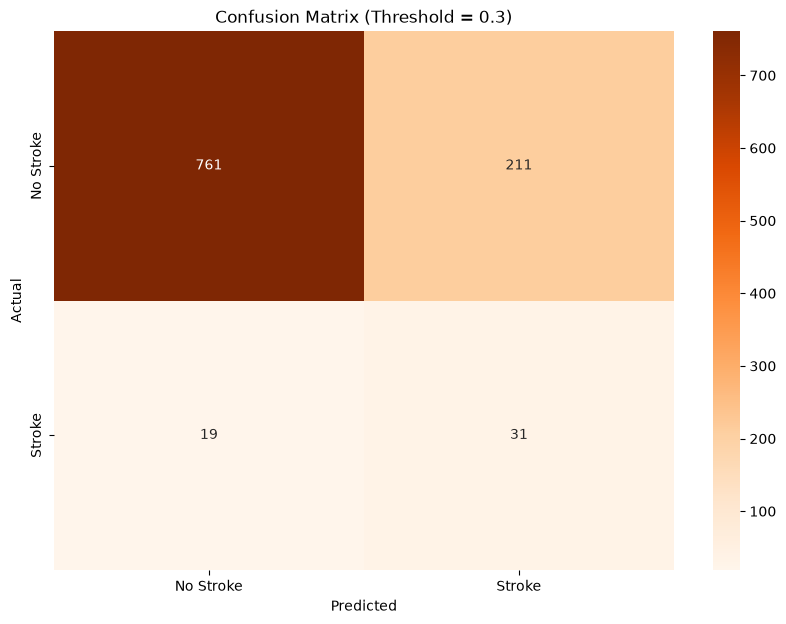

New Recall: 0.6200


In [47]:
# 1. Define the grid of hyperparameters to test
param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 8, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

# 2. Set up the base Random Forest and the random search
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=20,            # Tests 20 random combinations
    cv=5,                 # 5-fold cross-validation
    scoring='f1',         # Optimizes for finding stroke cases
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# 3. Fit the search on your SMOTE training data
print("Tuning hyperparameters... this might take a minute.")
rf_search.fit(X_train_resampled, y_train_resampled)

# 4. Save the best model back to your original variable name
rf_model = rf_search.best_estimator_
print(f"\nBest parameters found:\n{rf_search.best_params_}")

# --- APPLY CUSTOM THRESHOLD ---

# 1. Get the raw probabilities for the stroke class (Class 1)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Set a custom, lower threshold (e.g., 30% instead of 50%)
custom_threshold = 0.30

# 3. Create new predictions based on this threshold
y_pred_lower_threshold = (y_pred_proba >= custom_threshold).astype(int)

# 4. Check the new confusion matrix
cm_new = confusion_matrix(y_test, y_pred_lower_threshold)

plt.figure(figsize=(10,7))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Stroke', 'Stroke'], 
            yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {custom_threshold})')
plt.show()

print(f"New Recall: {recall_score(y_test, y_pred_lower_threshold):.4f}")

# 5. Overwrite y_pred so the rest of your notebook uses these new results!
y_pred = y_pred_lower_threshold

In [48]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7749510763209393


In [49]:
y_pred[:20]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [50]:
y_test[:20]

3725    0
4481    0
1545    0
1820    0
1262    0
3618    0
254     0
628     0
3426    0
2687    0
258     0
958     0
4434    0
2839    0
761     0
2177    0
3453    0
4005    0
1917    0
2166    0
Name: stroke, dtype: int64

In [51]:
print(classification_report(y_test, y_pred, target_names=['No Stroke','Stroke']))

              precision    recall  f1-score   support

   No Stroke       0.98      0.78      0.87       972
      Stroke       0.13      0.62      0.21        50

    accuracy                           0.77      1022
   macro avg       0.55      0.70      0.54      1022
weighted avg       0.93      0.77      0.84      1022



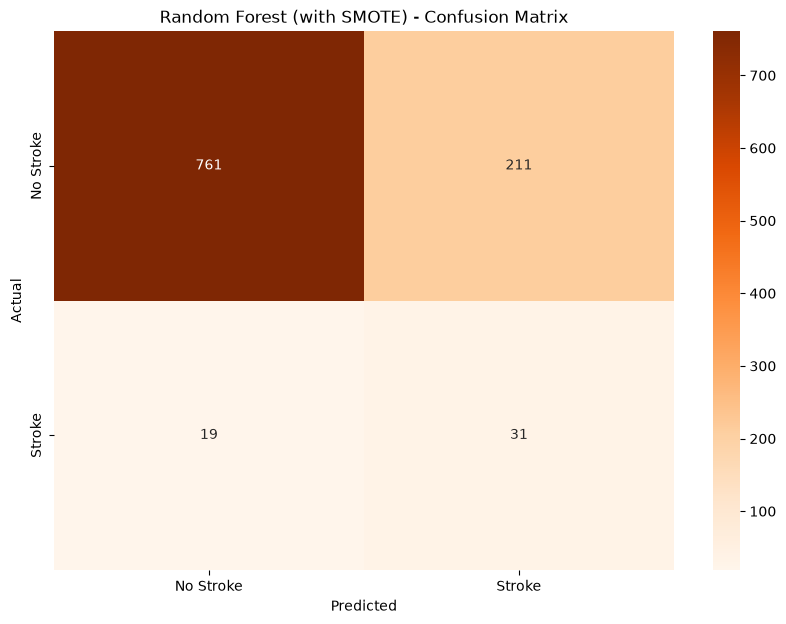

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Stroke','Stroke'], yticklabels=['No Stroke','Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest (with SMOTE) - Confusion Matrix')
plt.show()


**Full Evaluation Metrics**

In [53]:
print("=" * 60)
print("MODEL EVALUATION ON UNSEEN TEST DATA")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")


MODEL EVALUATION ON UNSEEN TEST DATA
Accuracy : 0.7750
Precision: 0.1281
Recall   : 0.6200
F1 Score : 0.2123
ROC-AUC  : 0.7747


**Feature Importance**

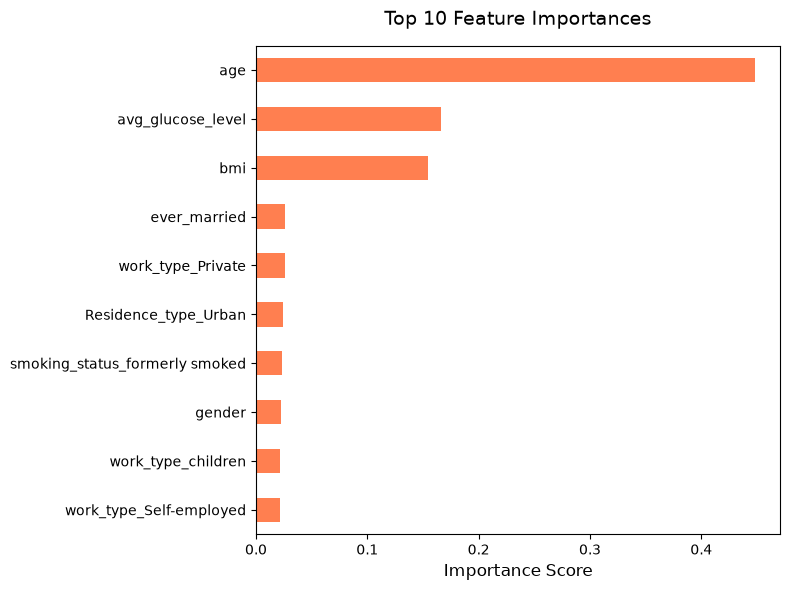

In [54]:
plt.figure(figsize=(8, 6))
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

feature_importance.tail(10).plot(kind='barh', color='coral')
plt.title('Top 10 Feature Importances', pad=15, fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


**ROC Curve**

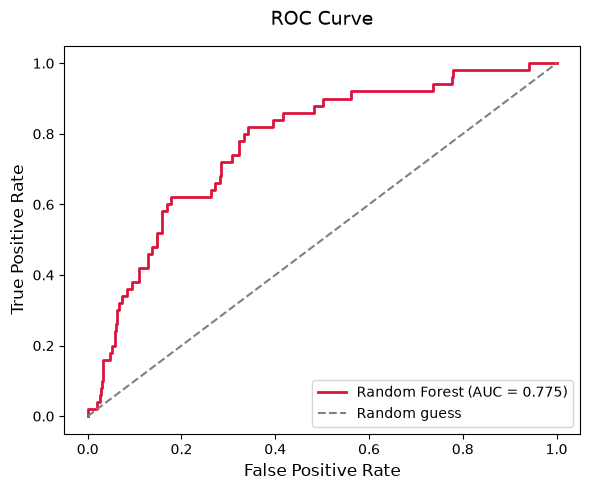

In [55]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", color="crimson", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("ROC Curve", pad=15, fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [57]:
# Save the tuned Random Forest model
joblib.dump(rf_model, 'stroke_rf_model.pkl')

# Save the fitted StandardScaler
joblib.dump(scaler, 'stroke_scaler.pkl')

# Save the exact column order so Streamlit formats the data correctly
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Files saved successfully! Ready for Streamlit.")

Files saved successfully! Ready for Streamlit.
